In [6]:
import importlib
from IPython.display import display

try:
    import helpers.preprocess as prep
    import helpers.solver as solv
    import helpers.output_writer as ow

    importlib.reload(prep)
    importlib.reload(solv)
    importlib.reload(ow)

    from helpers.preprocess import preprocess_model
    from helpers.solver import solve_complete_model
    from helpers.output_writer import write_run_outputs
except ImportError:
    import preprocess as prep
    import solver as solv
    import output_writer as ow

    importlib.reload(prep)
    importlib.reload(solv)
    importlib.reload(ow)

    from preprocess import preprocess_model
    from solver import solve_complete_model
    from output_writer import write_run_outputs

model_path = "inputs/validation/Validation files from previous examples/validation_3d_frame_with_member_loads.json"

_, clean_model, data, summary = preprocess_model(model_path)
package = solve_complete_model(clean_model, data)

output_dir, tables, global_summary, dof_summary = write_run_outputs(
    clean_model=clean_model,
    data=data,
    summary=summary,
    package=package,
    model_path=model_path,
    output_root="outputs/runs"
)

print(f"Outputs saved to {output_dir}")
print()

display(tables["model_summary"])
display(tables["node_displacements"])
display(tables["support_reactions"])
display(tables["element_local_end_forces"])
display(tables["element_derived_results"])

Outputs saved to outputs\runs\validation_3d_frame_with_member_loads



,model_name,length_unit,force_unit,n_nodes,n_elements,n_truss_elements,n_frame_elements,n_free_dofs,n_restrained_dofs,max_displacement_node,max_displacement_magnitude
0,validation_3d_frame_with_member_loads,m,kN,3,2,0,2,4,14,2,0.001128


,node_id,x,y,z,ux,uy,uz,rx,ry,rz,disp_mag,rot_mag
0,1,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.000000
1,2,0.0,10.0,0.0,0.000955,-0.000599,0.0,0.0,0.0,0.025391,0.001128,0.025391
2,3,8.0,10.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.021201,0.000000,0.021201


,node_id,x,y,z,Rx,Ry,Rz,Mx,My,Mz,reaction_force_mag,reaction_moment_mag
0,1,0.0,0.0,0.0,-126.815044,56.831399,0.0,0.0,0.0,222.80163,138.967130,222.80163
1,2,0.0,10.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.00000,0.000000,0.00000
2,3,8.0,10.0,0.0,-113.184956,18.168601,0.0,0.0,0.0,0.00000,114.633906,0.00000


,elem_id,type,node_i,node_j,Fx_i_local,Fy_i_local,Fz_i_local,Mx_i_local,My_i_local,Mz_i_local,Fx_j_local,Fy_j_local,Fz_j_local,Mx_j_local,My_j_local,Mz_j_local
0,1,3D_frame,1,2,56.831399,126.815044,0.0,0.0,0.0,222.801630,-56.831399,113.184956,0.0,0.0,0.0,-154.651192
1,2,3D_frame,2,3,113.184956,56.831399,0.0,0.0,0.0,154.651192,-113.184956,18.168601,0.0,0.0,0.0,0.000000


,elem_id,type,node_i,node_j,L,axial_i_local,axial_j_local,axial_abs_max,shear_y_abs_max,shear_z_abs_max,torsion_abs_max,moment_y_abs_max,moment_z_abs_max,moment_abs_max,stress_axial_i,stress_axial_j,stress_axial_abs_max
0,1,3D_frame,1,2,10.0,56.831399,-56.831399,56.831399,126.815044,0.0,0.0,0.0,222.801630,222.801630,11989.746613,-11989.746613,11989.746613
1,2,3D_frame,2,3,8.0,113.184956,-113.184956,113.184956,56.831399,0.0,0.0,0.0,154.651192,154.651192,23878.682737,-23878.682737,23878.682737


In [7]:
import pandas as pd

df_nodes = tables["node_displacements"].copy()

df_disp_key = df_nodes[df_nodes["node_id"].isin([2, 3])][
    ["node_id", "ux", "uy", "rz", "disp_mag", "rot_mag"]
].sort_values("node_id").reset_index(drop=True)

display(df_disp_key)

df_react = tables["support_reactions"].copy()

df_react_key = df_react[df_react["node_id"].isin([1, 3])][
    ["node_id", "Rx", "Ry", "Rz", "Mx", "My", "Mz"]
].sort_values("node_id").reset_index(drop=True)

display(df_react_key)

df_local = tables["element_local_end_forces"].copy()

df_local_key = df_local[df_local["elem_id"].isin([1, 2])][
    [
        "elem_id",
        "Fx_i_local", "Fy_i_local", "Fz_i_local",
        "Mx_i_local", "My_i_local", "Mz_i_local",
        "Fx_j_local", "Fy_j_local", "Fz_j_local",
        "Mx_j_local", "My_j_local", "Mz_j_local"
    ]
].sort_values("elem_id").reset_index(drop=True)

display(df_local_key)

benchmark_rows = [
    {"quantity": "Node 2 ux", "benchmark": 0.000955147309, "code": float(df_disp_key.loc[df_disp_key["node_id"] == 2, "ux"].iloc[0])},
    {"quantity": "Node 2 uy", "benchmark":  -0.000599487331, "code": float(df_disp_key.loc[df_disp_key["node_id"] == 2, "uy"].iloc[0])},
    {"quantity": "Node 2 rz", "benchmark": 0.025390966887, "code": float(df_disp_key.loc[df_disp_key["node_id"] == 2, "rz"].iloc[0])},
    {"quantity": "Node 3 rz", "benchmark": 0.021200704215, "code": float(df_disp_key.loc[df_disp_key["node_id"] == 3, "rz"].iloc[0])},

    {"quantity": "Node 1 Rx", "benchmark": -126.81504382729, "code": float(df_react_key.loc[df_react_key["node_id"] == 1, "Rx"].iloc[0])},
    {"quantity": "Node 1 Ry", "benchmark": 56.831398945727, "code": float(df_react_key.loc[df_react_key["node_id"] == 1, "Ry"].iloc[0])},
    {"quantity": "Node 1 Mz", "benchmark": 222.801629838714, "code": float(df_react_key.loc[df_react_key["node_id"] == 1, "Mz"].iloc[0])},

    {"quantity": "Node 3 Rx", "benchmark": -113.18495617271, "code": float(df_react_key.loc[df_react_key["node_id"] == 3, "Rx"].iloc[0])},
    {"quantity": "Node 3 Ry", "benchmark": 18.168601054273, "code": float(df_react_key.loc[df_react_key["node_id"] == 3, "Ry"].iloc[0])},
]

df_compare = pd.DataFrame(benchmark_rows)
df_compare["difference"] = df_compare["code"] - df_compare["benchmark"]

def pct_diff(row):
    b = row["benchmark"]
    if abs(b) < 1e-14:
        return None
    return 100.0 * (row["code"] - b) / b

df_compare["percent_difference"] = df_compare.apply(pct_diff, axis=1)
display(df_compare)

,node_id,ux,uy,rz,disp_mag,rot_mag
0,2,0.000955,-0.000599,0.025391,0.001128,0.025391
1,3,0.000000,0.000000,0.021201,0.000000,0.021201


,node_id,Rx,Ry,Rz,Mx,My,Mz
0,1,-126.815044,56.831399,0.0,0.0,0.0,222.80163
1,3,-113.184956,18.168601,0.0,0.0,0.0,0.00000


,elem_id,Fx_i_local,Fy_i_local,Fz_i_local,Mx_i_local,My_i_local,Mz_i_local,Fx_j_local,Fy_j_local,Fz_j_local,Mx_j_local,My_j_local,Mz_j_local
0,1,56.831399,126.815044,0.0,0.0,0.0,222.801630,-56.831399,113.184956,0.0,0.0,0.0,-154.651192
1,2,113.184956,56.831399,0.0,0.0,0.0,154.651192,-113.184956,18.168601,0.0,0.0,0.0,0.000000


,quantity,benchmark,code,difference,percent_difference
0,Node 2 ux,0.000955,0.000955,4.743466e-13,4.966214e-08
1,Node 2 uy,-0.000599,-0.000599,3.488723e-13,-5.819511e-08
2,Node 2 rz,0.025391,0.025391,-2.090030e-13,-8.231390e-10
3,Node 3 rz,0.021201,0.021201,-1.146305e-13,-5.406921e-10
4,Node 1 Rx,-126.815044,-126.815044,8.526513e-14,-6.723582e-14
5,Node 1 Ry,56.831399,56.831399,-9.947598e-14,-1.750370e-13
6,Node 1 Mz,222.801630,222.801630,3.694822e-13,1.658346e-13
7,Node 3 Rx,-113.184956,-113.184956,-7.105427e-14,6.277714e-14
8,Node 3 Ry,18.168601,18.168601,9.592327e-14,5.279618e-13


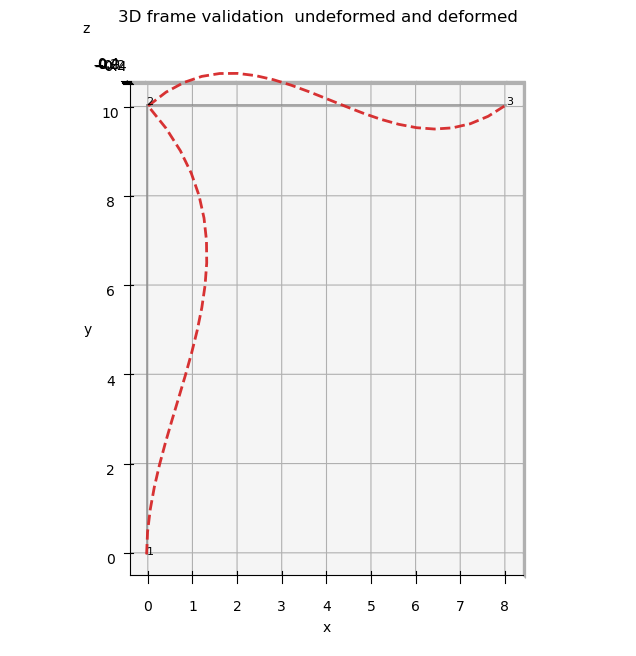

<Figure size 640x480 with 0 Axes>

In [12]:
import importlib
import matplotlib.pyplot as plt
from pathlib import Path

try:
    import helpers.plotting_simple as ps
    importlib.reload(ps)
    from helpers.plotting_simple import plot_structure_simple
except ImportError:
    import plotting_simple as ps
    importlib.reload(ps)
    from plotting_simple import plot_structure_simple

_ = plot_structure_simple(
    clean_model,
    data,
    U=package["results"]["U"],
    scale=35.0,
    selector="all",
    show_undeformed=True,
    show_deformed=True,
    show_node_labels=True,
    show_element_labels=False,
    title="3D frame validation  undeformed and deformed",
    view="xy",
    save_path="outputs/validation/simple_plots/3D_frame_validation",
)


plt.gcf().savefig(simple_plot_path, dpi=300, bbox_inches="tight")


plt.show()

In [9]:
import importlib

try:
    import helpers.plotting_plotly as pp3d
    importlib.reload(pp3d)
    from helpers.plotting_plotly import plot_structure_plotly
except ImportError:
    import plotting_plotly as pp3d
    importlib.reload(pp3d)
    from plotting_plotly import plot_structure_plotly

fig = plot_structure_plotly(
    clean_model,
    data,
    U=package["results"]["U"],
    scale=35.0,
    selector="all",
    show_undeformed=True,
    show_deformed=True,
    show_nodes=True,
    show_node_labels=True,
    show_element_hover=True,
    show_member_loads=True,
    member_load_scale=0.02,
    title="3D frame validation interactive with member loads",
    save_html="outputs/validation/plotly_plots/validation_3d_frame_interactive.html",
    save_png="outputs/validation/plotly_plots/validation_3d_frame_interactive.png",
)

fig.show()